

> ***First time spectogram generation(preprocessing)***



In [ ]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt

def save_spectrogram(wav_path, out_path):
    y, sr = librosa.load(wav_path, sr=None)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_DB = librosa.power_to_db(S, ref=np.max)
    plt.figure(figsize=(2.24, 2.24))
    plt.axis('off')
    librosa.display.specshow(S_DB, sr=sr, x_axis='time', y_axis='mel')
    plt.savefig(out_path, bbox_inches='tight', pad_inches=0)
    plt.close()
root_dir = '/content/drive/MyDrive/audio_speech_actors_01-24'
spec_dir = '/content/spectrograms'
os.makedirs(spec_dir, exist_ok=True)

for actor in os.listdir(root_dir):
    actor_path = os.path.join(root_dir, actor)
    if not os.path.isdir(actor_path):
        continue 
    for wav_file in os.listdir(actor_path):
        out_path = os.path.join(spec_dir, f'{actor}_{wav_file[:-4]}.png')
        save_spectrogram(os.path.join(actor_path, wav_file), out_path)



> ***CNN + BLSTM + ATTENTION WITH GWO SEARCH***

Using device: cuda
Loaded: (1440, 128, 128) Labels: (1440,)
Model/Training defaults (pre-optimization): {'cnn1_filters': 32, 'cnn2_filters': 64, 'cnn3_filters': 128, 'lstm_hidden': 128, 'dropout_rate': 0.3, 'optimizer': 'Adam', 'lr': 0.001, 'weight_decay': 0.0, 'batch_size': 32}
GWO Iter 1/4 | Best Acc: 33.68%
GWO Iter 2/4 | Best Acc: 47.92%
GWO Iter 3/4 | Best Acc: 51.74%
GWO Iter 4/4 | Best Acc: 61.46%

Best Params Found: {'lr': 0.0002383316607469301, 'weight_decay': 1.885896084509817e-05, 'dropout_rate': 0.2533733318904682, 'lstm_hidden': 128, 'cnn1_filters': 64, 'cnn2_filters': 32, 'cnn3_filters': 192, 'optimizer': 'Adam', 'batch_size': 16}
Validation Accuracy: 61.46%
Epoch 1/50, Test Accuracy: 35.76%
Epoch 2/50, Test Accuracy: 43.75%
Epoch 3/50, Test Accuracy: 47.92%
Epoch 4/50, Test Accuracy: 54.17%
Epoch 5/50, Test Accuracy: 52.43%
Epoch 6/50, Test Accuracy: 47.22%
Epoch 7/50, Test Accuracy: 60.42%
Epoch 8/50, Test Accuracy: 60.07%
Epoch 9/50, Test Accuracy: 64.24%
Epoch 10/50, 

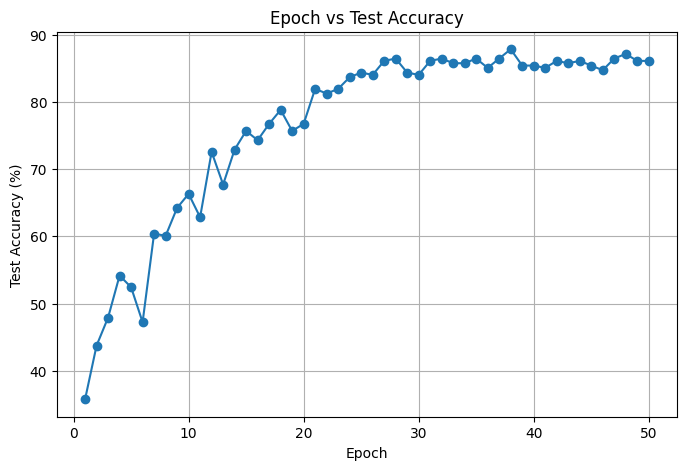

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from skimage import io, color
from skimage.transform import resize
import matplotlib.pyplot as plt
import random
import gc


#Gpu Setup

seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

spec_dir = '/content/drive/MyDrive/spectrograms'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

#Data loading and Encoding
def get_emotion_id(filename):
    try:
        if '_' in filename:
            filename = filename.split('_', 1)[-1]
        return int(filename.split('-')[2])
    except Exception:
        return None

def load_spectrogram_image(image_path, resize_dim=128):
    img = io.imread(image_path)
    if img.ndim == 2:
        img_gray = img
    else:
        if img.shape[2] == 4:
            img = color.rgba2rgb(img)
        img_gray = color.rgb2gray(img)
    img_resized = resize(img_gray, (resize_dim, resize_dim))
    return img_resized

features, labels = [], []

for fname in os.listdir(spec_dir):
    fpath = os.path.join(spec_dir, fname)
    label = get_emotion_id(fname)
    if label is not None:
        img = load_spectrogram_image(fpath)
        features.append(img)
        labels.append(label - 1)  

features = np.array(features)
labels = np.array(labels)
print("Loaded:", features.shape, "Labels:", labels.shape)

features = features[:, np.newaxis, :, :]

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=seed, stratify=labels
)

X_train_tensor = torch.tensor(X_train).float().to(device)
y_train_tensor = torch.tensor(y_train).long().to(device)
X_test_tensor  = torch.tensor(X_test ).float().to(device)
y_test_tensor  = torch.tensor(y_test ).long().to(device)


default_batch_size = 32




class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)  
        out = torch.sum(weights * x, dim=1)          
        return out

class CNN_BLSTM_Attention(nn.Module):
    def __init__(self, num_classes,
                 lstm_hidden=128,
                 dropout_rate=0.3,
                 cnn1_filters=32,
                 cnn2_filters=64,
                 cnn3_filters=128):
        super().__init__()
  
        self.cnn = nn.Sequential(
            nn.Conv2d(1, cnn1_filters, 3, padding=1),
            nn.BatchNorm2d(cnn1_filters),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(cnn1_filters, cnn2_filters, 3, padding=1),
            nn.BatchNorm2d(cnn2_filters),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(cnn2_filters, cnn3_filters, 3, padding=1),
            nn.BatchNorm2d(cnn3_filters),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.lstm_hidden = lstm_hidden

        self.lstm = nn.LSTM(cnn3_filters * 16, lstm_hidden, batch_first=True, bidirectional=True)
        self.attention = Attention(lstm_hidden * 2)
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        cnn_out = self.cnn(x)                   
        b, c, h, w = cnn_out.shape
        cnn_out = cnn_out.permute(0, 3, 1, 2).reshape(b, w, c * h)  
        lstm_out, _ = self.lstm(cnn_out)       
        attn_out = self.attention(lstm_out)       
        logits = self.fc(self.dropout(attn_out)) 
        return logits

num_classes = len(np.unique(y_train))


initial_defaults = {
    "cnn1_filters": 32,
    "cnn2_filters": 64,
    "cnn3_filters": 128,
    "lstm_hidden": 128,
    "dropout_rate": 0.3,
    "optimizer": "Adam",
    "lr": 1e-3,
    "weight_decay": 0.0,
    "batch_size": default_batch_size
}
print("Model/Training defaults (pre-optimization):", initial_defaults)


# GREY WOLF OPTIMIZER (EXPANDED SEARCH SPACE)

def make_optimizer(params, model_params):
    opt_name = params['optimizer']
    lr = params['lr']
    wd = params['weight_decay']
    if opt_name == 'Adam':
        return optim.Adam(model_params, lr=lr, weight_decay=wd, betas=(0.9, 0.999))
    elif opt_name == 'AdamW':
        return optim.AdamW(model_params, lr=lr, weight_decay=wd, betas=(0.9, 0.999))
    else:  # RMSprop
        return optim.RMSprop(model_params, lr=lr, weight_decay=wd, momentum=0.9)

def grey_wolf_optimizer(X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor,
                        n_wolves=6, iterations=4, epochs_per_wolf=4):


    # --- helpers ---
    def random_params():
        return {
            'lr': 10 ** random.uniform(-4, -2),
            'weight_decay': 10 ** random.uniform(-6, -3),  
            'dropout_rate': random.uniform(0.2, 0.5),
            'lstm_hidden': random.choice([64, 96, 128, 160, 192, 256]),
            'cnn1_filters': random.choice([16, 32, 48]),
            'cnn2_filters': random.choice([32, 64, 96]),
            'cnn3_filters': random.choice([64, 128, 192]),
            'optimizer': random.choice(['Adam', 'AdamW', 'RMSprop']),
            'batch_size': random.choice([16, 32, 64]),
        }

    def clamp_params(p):
        p['lr'] = float(min(max(p['lr'], 1e-4), 1e-2))
        p['weight_decay'] = float(min(max(p['weight_decay'], 0.0), 1e-3))
        p['dropout_rate'] = float(min(max(p['dropout_rate'], 0.2), 0.5))

        def snap(val, choices):
            return min(choices, key=lambda c: abs(c - val))
        p['lstm_hidden']  = int(snap(int(p['lstm_hidden']),  [64, 96, 128,132,140,148, 160, 192, 256]))
        p['cnn1_filters'] = int(snap(int(p['cnn1_filters']), [16, 32, 48,60,64]))
        p['cnn2_filters'] = int(snap(int(p['cnn2_filters']), [32,50,55, 64, 96]))
        p['cnn3_filters'] = int(snap(int(p['cnn3_filters']), [64, 128,150,164,182,190, 192,212]))
        if p.get('optimizer') not in ['Adam','AdamW','RMSprop']:
            p['optimizer'] = 'Adam'
        p['batch_size'] = int(snap(int(p['batch_size']), [16, 32, 64]))
        return p

    def fitness(params):
        torch.cuda.empty_cache(); gc.collect()

        model = CNN_BLSTM_Attention(
            num_classes,
            lstm_hidden=params['lstm_hidden'],
            dropout_rate=params['dropout_rate'],
            cnn1_filters=params['cnn1_filters'],
            cnn2_filters=params['cnn2_filters'],
            cnn3_filters=params['cnn3_filters']
        ).to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer_ = make_optimizer(params, model.parameters())


        train_dataset_local = TensorDataset(X_train_tensor, y_train_tensor)
        train_loader_local = DataLoader(train_dataset_local, batch_size=params['batch_size'], shuffle=True)

        model.train()
        for _ in range(epochs_per_wolf):
            for xb, yb in train_loader_local:
                optimizer_.zero_grad()
                out = model(xb)
                loss = criterion(out, yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer_.step()

        model.eval()
        with torch.no_grad():
            preds = torch.argmax(model(X_val_tensor), dim=1)
            acc = (preds == y_val_tensor).float().mean().item()
        return acc

    # Initializing wolves
    wolves = [random_params() for _ in range(n_wolves)]
    fitness_vals = [fitness(w) for w in wolves]

    for t in range(iterations):
        alpha_idx = int(np.argmax(fitness_vals))
        alpha = wolves[alpha_idx]
        print(f"GWO Iter {t+1}/{iterations} | Best Acc: {fitness_vals[alpha_idx]*100:.2f}%")

#Linearly Decrease a as in algorithm
        a = 2 - t * (2 / iterations)

        new_wolves, new_fitness = [], []
        for i in range(n_wolves):
            wolf = wolves[i]
            new_wolf = {}
            for k in wolf:

                if k == 'optimizer':

                    choices = ['Adam', 'AdamW', 'RMSprop']
                    idx = choices.index(wolf[k])
                    alpha_idx_opt = choices.index(alpha[k])
                    r1, r2 = random.random(), random.random()
                    A = 2 * a * r1 - a
                    C = 2 * r2
                    D = abs(C * alpha_idx_opt - idx)
                    new_idx = int(round(alpha_idx_opt - A * D))
                    new_idx = min(max(new_idx, 0), len(choices)-1)
                    new_wolf[k] = choices[new_idx]
                    continue


                r1, r2 = random.random(), random.random()
                A = 2 * a * r1 - a
                C = 2 * r2
                D = abs(C * (alpha[k]) - (wolf[k]))
                new_val = alpha[k] - A * D
                new_wolf[k] = new_val

            new_wolf = clamp_params(new_wolf)
            acc = fitness(new_wolf)
            new_wolves.append(new_wolf)
            new_fitness.append(acc)

        # Keep top n_wolves
        combined_wolves = wolves + new_wolves
        combined_fitness = fitness_vals + new_fitness
        best_idx = np.argsort(combined_fitness)[-n_wolves:]
        wolves = [combined_wolves[i] for i in best_idx]
        fitness_vals = [combined_fitness[i] for i in best_idx]

    best_idx = int(np.argmax(fitness_vals))
    return wolves[best_idx], fitness_vals[best_idx]


# RUN GWO SEARCH

best_params, best_acc = grey_wolf_optimizer(
    X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor,
    n_wolves=6, iterations=4, epochs_per_wolf=4
)
print("\nBest Params Found:", best_params)
print(f"Validation Accuracy: {best_acc*100:.2f}%")


# TRAIN FINAL MODEL WITH BEST PARAMS

final_model = CNN_BLSTM_Attention(
    num_classes,
    lstm_hidden=best_params['lstm_hidden'],
    dropout_rate=best_params['dropout_rate'],
    cnn1_filters=best_params['cnn1_filters'],
    cnn2_filters=best_params['cnn2_filters'],
    cnn3_filters=best_params['cnn3_filters']
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_final = make_optimizer(best_params, final_model.parameters())


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)

epochs = 50
epoch_acc = []

for epoch in range(epochs):
    final_model.train()
    for xb, yb in train_loader:
        optimizer_final.zero_grad()
        out = final_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=5.0)
        optimizer_final.step()

    final_model.eval()
    with torch.no_grad():
        preds = torch.argmax(final_model(X_test_tensor), dim=1)
        acc = (preds == y_test_tensor).float().mean().item()
        epoch_acc.append(acc)
    print(f"Epoch {epoch+1}/{epochs}, Test Accuracy: {acc*100:.2f}%")


# PLOT RESULTS

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), [a*100 for a in epoch_acc], marker='o')
plt.title("Epoch vs Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.grid(True)
plt.show()


> ***Second run on the parameters found above***

Using device: cuda
Loaded: (1440, 128, 128) Labels: (1440,)
Epoch 1/50 | Train Acc: 24.48% | Test Acc: 33.68%
Epoch 2/50 | Train Acc: 32.55% | Test Acc: 33.33%
Epoch 3/50 | Train Acc: 41.75% | Test Acc: 44.79%
Epoch 4/50 | Train Acc: 50.17% | Test Acc: 51.74%
Epoch 5/50 | Train Acc: 55.03% | Test Acc: 55.90%
Epoch 6/50 | Train Acc: 57.99% | Test Acc: 48.96%
Epoch 7/50 | Train Acc: 63.28% | Test Acc: 64.58%
Epoch 8/50 | Train Acc: 66.67% | Test Acc: 63.19%
Epoch 9/50 | Train Acc: 71.27% | Test Acc: 61.46%
Epoch 10/50 | Train Acc: 73.70% | Test Acc: 63.89%
Epoch 11/50 | Train Acc: 76.91% | Test Acc: 69.79%
Epoch 12/50 | Train Acc: 80.03% | Test Acc: 73.61%
Epoch 13/50 | Train Acc: 81.94% | Test Acc: 74.65%
Epoch 14/50 | Train Acc: 87.24% | Test Acc: 72.57%
Epoch 15/50 | Train Acc: 88.19% | Test Acc: 76.39%
Epoch 16/50 | Train Acc: 92.53% | Test Acc: 76.74%
Epoch 17/50 | Train Acc: 92.27% | Test Acc: 78.12%
Epoch 18/50 | Train Acc: 95.92% | Test Acc: 79.17%
Epoch 19/50 | Train Acc: 96.35%

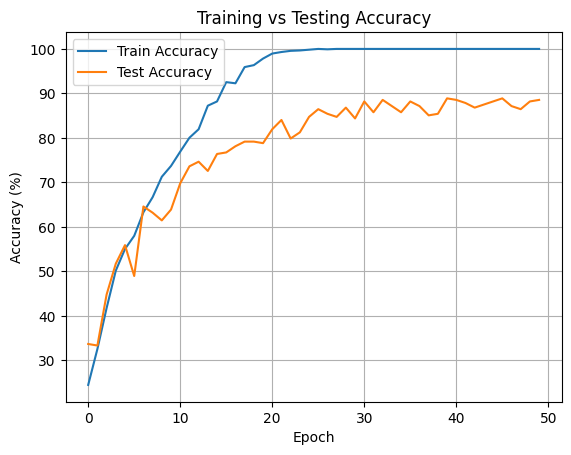

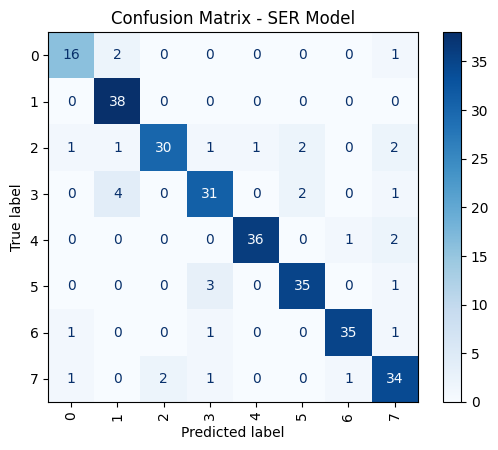

✅ Model Saved Successfully!
✅ Best Params Saved!


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader
from skimage import io, color
from skimage.transform import resize
import matplotlib.pyplot as plt
import json


# DEVICE SETUP

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

spec_dir = '/content/drive/MyDrive/spectrograms'


# LOAD DATA

def get_emotion_id(filename):
    try:
        if '_' in filename:
            filename = filename.split('_', 1)[-1]
        return int(filename.split('-')[2])
    except:
        return None

def load_spectrogram_image(image_path, resize_dim=128):
    img = io.imread(image_path)
    if img.ndim == 2:
        img_gray = img
    else:
        if img.shape[2] == 4:
            img = color.rgba2rgb(img)
        img_gray = color.rgb2gray(img)
    img_resized = resize(img_gray, (resize_dim, resize_dim))
    return img_resized

features, labels = [], []
for fname in os.listdir(spec_dir):
    fpath = os.path.join(spec_dir, fname)
    label = get_emotion_id(fname)
    if label is not None:
        img = load_spectrogram_image(fpath)
        features.append(img)
        labels.append(label - 1)

features = np.array(features)
labels = np.array(labels)
print("Loaded:", features.shape, "Labels:", labels.shape)

features = features[:, np.newaxis, :, :]

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

X_train_tensor = torch.tensor(X_train).float().to(device)
y_train_tensor = torch.tensor(y_train).long().to(device)
X_test_tensor  = torch.tensor(X_test ).float().to(device)
y_test_tensor  = torch.tensor(y_test ).long().to(device)


# MODEL DEFINITIONS

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)
        return torch.sum(weights * x, dim=1)

class CNN_BLSTM_Attention(nn.Module):
    def __init__(self, num_classes,
                 lstm_hidden=128,
                 dropout_rate=0.3,
                 cnn1_filters=32,
                 cnn2_filters=64,
                 cnn3_filters=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, cnn1_filters, 3, padding=1),
            nn.BatchNorm2d(cnn1_filters),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(cnn1_filters, cnn2_filters, 3, padding=1),
            nn.BatchNorm2d(cnn2_filters),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(cnn2_filters, cnn3_filters, 3, padding=1),
            nn.BatchNorm2d(cnn3_filters),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.lstm = nn.LSTM(cnn3_filters * 16, lstm_hidden,
                            batch_first=True, bidirectional=True)
        self.attention = Attention(lstm_hidden * 2)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)

    def forward(self, x):
        cnn_out = self.cnn(x)
        b, c, h, w = cnn_out.shape
        seq = cnn_out.permute(0, 3, 1, 2).reshape(b, w, c*h)
        lstm_out, _ = self.lstm(seq)
        attn = self.attention(lstm_out)
        return self.fc(self.dropout(attn))

num_classes = len(np.unique(y_train))


# USE BEST PARAMETERS FROM GWO

best_params = {
    'lr': 0.0002383316607469301,
    'weight_decay': 1.885896084509817e-05,
    'dropout_rate': 0.2533733318904682,
    'lstm_hidden': 128,
    'cnn1_filters': 64,
    'cnn2_filters': 32,
    'cnn3_filters': 192,
    'optimizer': 'Adam',
    'batch_size': 16
}

final_model = CNN_BLSTM_Attention(
    num_classes,
    lstm_hidden=best_params['lstm_hidden'],
    dropout_rate=best_params['dropout_rate'],
    cnn1_filters=best_params['cnn1_filters'],
    cnn2_filters=best_params['cnn2_filters'],
    cnn3_filters=best_params['cnn3_filters']
).to(device)

optimizer = optim.Adam(
    final_model.parameters(),
    lr=best_params['lr'],
    weight_decay=best_params['weight_decay']
)

criterion = nn.CrossEntropyLoss()
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=best_params['batch_size'],
    shuffle=True
)


# TRAIN FINAL MODEL

epochs = 50
train_acc = []
test_acc = []

for epoch in range(epochs):

    final_model.train()
    correct_train = 0
    total_train = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = final_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        preds_train = torch.argmax(out, dim=1)
        correct_train += (preds_train == yb).sum().item()
        total_train += yb.size(0)

    epoch_train_acc = correct_train / total_train
    train_acc.append(epoch_train_acc)

    # ---- TEST ----
    final_model.eval()
    with torch.no_grad():
        preds_test = torch.argmax(final_model(X_test_tensor), dim=1)
        epoch_test_acc = (preds_test == y_test_tensor).float().mean().item()
        test_acc.append(epoch_test_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {epoch_train_acc*100:.2f}% | Test Acc: {epoch_test_acc*100:.2f}%")


# PLOT TRAIN & TEST ACCURACY

plt.plot([a*100 for a in train_acc], label="Train Accuracy")
plt.plot([a*100 for a in test_acc], label="Test Accuracy")
plt.title("Training vs Testing Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()


# CONFUSION MATRIX

final_model.eval()
with torch.no_grad():
    y_pred = torch.argmax(final_model(X_test_tensor), dim=1).cpu().numpy()
    y_true = y_test_tensor.cpu().numpy()

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title("Confusion Matrix - SER Model")
plt.show()


# SAVE MODEL + PARAMS

torch.save(final_model.state_dict(), "/content/drive/MyDrive/final_ser_model.pth")
print("✅ Model Saved Successfully!")

with open("/content/drive/MyDrive/best_params.json", "w") as f:
    json.dump(best_params, f, indent=4)
print("✅ Best Params Saved!")


> ***GWO SER WITH 5X DATA AUGMENTATION ***

Using device: cuda
Building 5x augmented dataset from audio (this is the heavy step)...
Total samples after 5x augmentation: 7200
Specs shape: (7200, 128, 128) Labels shape: (7200,)
Train: torch.Size([5760, 1, 128, 128]) Test: torch.Size([1440, 1, 128, 128])
Num classes: 8
GWO Iter 1/3 | Best Acc so far: 63.26%
GWO Iter 2/3 | Best Acc so far: 67.57%
GWO Iter 3/3 | Best Acc so far: 68.06%

Best Params Found by GWO: {'lr': 0.00018863471747159323, 'weight_decay': 0.0002780837800650263, 'dropout_rate': 0.2, 'lstm_hidden': 160, 'cnn1_filters': 32, 'cnn2_filters': 16, 'cnn3_filters': 16, 'optimizer': 'RMSprop', 'batch_size': 32}
GWO Validation Accuracy: 69.58%
Epoch 1/50 | Train Acc: 31.74% | Test Acc: 48.40%
Epoch 2/50 | Train Acc: 52.97% | Test Acc: 57.71%
Epoch 3/50 | Train Acc: 64.91% | Test Acc: 68.68%
Epoch 4/50 | Train Acc: 72.40% | Test Acc: 74.17%
Epoch 5/50 | Train Acc: 80.21% | Test Acc: 82.29%
Epoch 6/50 | Train Acc: 85.05% | Test Acc: 86.53%
Epoch 7/50 | Train Acc: 88.70% | Test

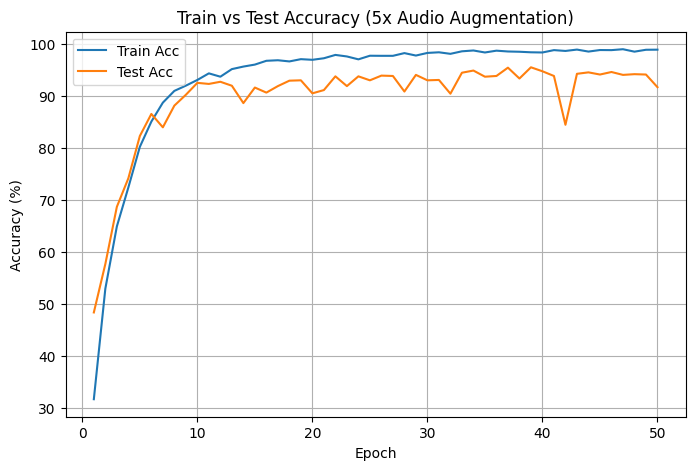

In [ ]:

# SER on RAVDESS with 5x Audio Augmentation 



import os
import random
import gc

import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from skimage.transform import resize
import matplotlib.pyplot as plt

#Device/DRIVE GPU SETUP 
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


audio_dir = "/content/drive/MyDrive/audio_speech_actors_01-24" 

sample_rate = 16000
resize_dim = 128 


# RAVDESS LABEL ENCODING

def get_emotion_id_from_ravdess(filename):

    RAVDESS naming: '03-01-05-02-02-01-12.wav'

    try:
        base = os.path.basename(filename)
        parts = base.split('.')[0].split('-')
        return int(parts[2]) 
    except Exception:
        return None





def augment_audio_4x(y, sr):
    aug_list = []

    # 1. Gaussian noise
    noise = np.random.normal(0, 0.005, y.shape)
    aug_list.append(y + noise)

    # 2. Time shift (±25% length)
    max_shift = int(0.25 * len(y))
    if max_shift > 0:
        shift = random.randint(-max_shift, max_shift)
        aug_list.append(np.roll(y, shift))
    else:
        aug_list.append(y.copy())

    # 3. Pitch shift (±2 semitones)
    try:
        aug_list.append(librosa.effects.pitch_shift(y, sr, n_steps=random.choice([-2, 2])))
    except Exception:
        aug_list.append(y.copy())

    # 4. Time stretch (0.8x or 1.2x)
    rate = random.choice([0.8, 1.2])
    try:
        stretched = librosa.effects.time_stretch(y, rate)
        if len(stretched) > 0:
            aug_list.append(stretched)
        else:
            aug_list.append(y.copy())
    except Exception:
        aug_list.append(y.copy())


    return aug_list


# MEL-SPECTROGRAM CREATION (in RAM only for avoiding I/O drive delay )

def audio_to_mel_spec(y, sr, resize_dim=128):
    """
    Convert 1D audio to 128 x 128 Mel-spectrogram.
    """
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=256,
        n_mels=resize_dim
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)  

#Resize MEl SPECTOGRAM
    mel_resized = resize(mel_db, (resize_dim, resize_dim), mode='reflect', anti_aliasing=True)
    return mel_resized.astype(np.float32)


all_specs = []
all_labels = []

print("Building 5x augmented dataset from audio (this is the heavy step)...")

for root, dirs, files in os.walk(audio_dir):
    for fname in files:
        if not fname.lower().endswith(".wav"):
            continue

        fpath = os.path.join(root, fname)
        emotion_id = get_emotion_id_from_ravdess(fname)
        if emotion_id is None:
            continue


        label = emotion_id - 1


        try:
            y, sr = librosa.load(fpath, sr=sample_rate, mono=True)
        except Exception as e:
            print("Error loading:", fpath, "->", e)
            continue



        # 1) Original
        spec_orig = audio_to_mel_spec(y, sr, resize_dim)
        all_specs.append(spec_orig)
        all_labels.append(label)


        aug_audios = augment_audio_4x(y, sr)
        for y_aug in aug_audios:
            spec_aug = audio_to_mel_spec(y_aug, sr, resize_dim)
            all_specs.append(spec_aug)
            all_labels.append(label)

print("Total samples after 5x augmentation:", len(all_specs))

all_specs = np.stack(all_specs, axis=0)  
all_labels = np.array(all_labels)
print("Specs shape:", all_specs.shape, "Labels shape:", all_labels.shape)


all_specs = all_specs[:, np.newaxis, :, :]


# TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    all_specs, all_labels, test_size=0.2, random_state=seed, stratify=all_labels
)

X_train_tensor = torch.tensor(X_train).float().to(device)
y_train_tensor = torch.tensor(y_train).long().to(device)
X_test_tensor  = torch.tensor(X_test ).float().to(device)
y_test_tensor  = torch.tensor(y_test ).long().to(device)

print("Train:", X_train_tensor.shape, "Test:", X_test_tensor.shape)


# BASELINE MODEL: CNN + BLSTM + ATTENTION

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (B, T, H)
        weights = torch.softmax(self.attn(x), dim=1)  
        out = torch.sum(weights * x, dim=1)          
        return out

class CNN_BLSTM_Attention(nn.Module):
    def __init__(self, num_classes,
                 lstm_hidden=128,
                 dropout_rate=0.3,
                 cnn1_filters=32,
                 cnn2_filters=64,
                 cnn3_filters=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, cnn1_filters, 3, padding=1),
            nn.BatchNorm2d(cnn1_filters),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(cnn1_filters, cnn2_filters, 3, padding=1),
            nn.BatchNorm2d(cnn2_filters),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(cnn2_filters, cnn3_filters, 3, padding=1),
            nn.BatchNorm2d(cnn3_filters),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.lstm_hidden = lstm_hidden
        self.lstm = nn.LSTM(cnn3_filters * 16,
                            lstm_hidden,
                            batch_first=True,
                            bidirectional=True)
        self.attention = Attention(lstm_hidden * 2)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)

    def forward(self, x):
     
        cnn_out = self.cnn(x)            
        b, c, h, w = cnn_out.shape          
        seq = cnn_out.permute(0, 3, 1, 2).reshape(b, w, c*h)  
        lstm_out, _ = self.lstm(seq)        
        attn = self.attention(lstm_out)     
        logits = self.fc(self.dropout(attn))
        return logits

num_classes = len(np.unique(y_train))
print("Num classes:", num_classes)


def make_optimizer(params, model_params):
    opt_name = params['optimizer']
    lr = params['lr']
    wd = params['weight_decay']
    if opt_name == 'Adam':
        return optim.Adam(model_params, lr=lr, weight_decay=wd)
    elif opt_name == 'AdamW':
        return optim.AdamW(model_params, lr=lr, weight_decay=wd)
    else:
        return optim.RMSprop(model_params, lr=lr, weight_decay=wd, momentum=0.9)

def grey_wolf_optimizer(X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor,
                        n_wolves=4, iterations=3, epochs_per_wolf=3):

    def random_params():
        return {
            'lr': 10 ** random.uniform(-4, -2),
            'weight_decay': 10 ** random.uniform(-6, -3),
            'dropout_rate': random.uniform(0.2, 0.5),
            'lstm_hidden': random.choice([64, 96, 128, 160]),
            'cnn1_filters': random.choice([16, 32, 48, 64]),
            'cnn2_filters': random.choice([32, 64, 96]),
            'cnn3_filters': random.choice([64, 96, 128, 160]),
            'optimizer': random.choice(['Adam', 'AdamW', 'RMSprop']),
            'batch_size': random.choice([16, 32, 64]),
        }

    def clamp_params(p):
        def snap(val, choices):
            return min(choices, key=lambda c: abs(c - val))

        p['lr'] = float(min(max(p['lr'], 1e-4), 1e-2))
        p['weight_decay'] = float(min(max(p['weight_decay'], 0.0), 1e-3))
        p['dropout_rate'] = float(min(max(p['dropout_rate'], 0.2), 0.5))

        valid_cnn = [16, 32, 48, 64, 96, 128]
        valid_lstm = [64, 96, 128]
        valid_bs   = [16, 32, 64]

        p['cnn1_filters'] = int(snap(int(p['cnn1_filters']), valid_cnn))
        p['cnn2_filters'] = int(snap(int(p['cnn2_filters']), valid_cnn))
        p['cnn3_filters'] = int(snap(int(p['cnn3_filters']), valid_cnn))
        p['lstm_hidden']  = int(snap(int(p['lstm_hidden']),  valid_lstm))
        p['batch_size']   = int(snap(int(p['batch_size']),   valid_bs))

        if p.get('optimizer') not in ['Adam', 'AdamW', 'RMSprop']:
            p['optimizer'] = 'Adam'

        return p

    def fitness(params):
        torch.cuda.empty_cache()
        gc.collect()

        model = CNN_BLSTM_Attention(
            num_classes,
            lstm_hidden=params['lstm_hidden'],
            dropout_rate=params['dropout_rate'],
            cnn1_filters=params['cnn1_filters'],
            cnn2_filters=params['cnn2_filters'],
            cnn3_filters=params['cnn3_filters']
        ).to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer_ = make_optimizer(params, model.parameters())

        train_loader_local = DataLoader(
            TensorDataset(X_train_tensor, y_train_tensor),
            batch_size=params['batch_size'],
            shuffle=True
        )

        model.train()
        for _ in range(epochs_per_wolf):
            for xb, yb in train_loader_local:
                optimizer_.zero_grad()
                out = model(xb)
                loss = criterion(out, yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer_.step()

        model.eval()
        with torch.no_grad():
            preds = torch.argmax(model(X_val_tensor), dim=1)
            acc = (preds == y_val_tensor).float().mean().item()

        return acc

    # Initializing wolves
    wolves = [random_params() for _ in range(n_wolves)]
    fitness_vals = [fitness(w) for w in wolves]

    for t in range(iterations):
        alpha_idx = int(np.argmax(fitness_vals))
        alpha = wolves[alpha_idx]
        print(f"GWO Iter {t+1}/{iterations} | Best Acc so far: {fitness_vals[alpha_idx]*100:.2f}%")

        a = 2 - t * (2 / iterations)

        new_wolves, new_fitness = [], []
        for i in range(n_wolves):
            wolf = wolves[i]
            new_wolf = {}
            for k in wolf:
                if k == 'optimizer':
                    # keep alpha or random new
                    new_wolf[k] = alpha[k] if random.random() < 0.5 else random.choice(['Adam', 'AdamW', 'RMSprop'])
                    continue

                r1, r2 = random.random(), random.random()
                A = 2 * a * r1 - a
                C = 2 * r2
                D = abs(C * alpha[k] - wolf[k])
                new_val = alpha[k] - A * D
                new_wolf[k] = new_val

            new_wolf = clamp_params(new_wolf)
            acc = fitness(new_wolf)
            new_wolves.append(new_wolf)
            new_fitness.append(acc)

        combined_wolves = wolves + new_wolves
        combined_fitness = fitness_vals + new_fitness
        best_idx = np.argsort(combined_fitness)[-n_wolves:]

        wolves = [combined_wolves[i] for i in best_idx]
        fitness_vals = [combined_fitness[i] for i in best_idx]

    best_idx = int(np.argmax(fitness_vals))
    return wolves[best_idx], fitness_vals[best_idx]


#Running GWO

best_params, best_acc = grey_wolf_optimizer(
    X_train_tensor, y_train_tensor,
    X_test_tensor, y_test_tensor,
    n_wolves=4, iterations=3, epochs_per_wolf=3
)

print("\nBest Params Found by GWO:", best_params)
print(f"GWO Validation Accuracy: {best_acc*100:.2f}%")

#EPoch Training on Best Parameteres found by GWO
final_model = CNN_BLSTM_Attention(
    num_classes,
    lstm_hidden=best_params['lstm_hidden'],
    dropout_rate=best_params['dropout_rate'],
    cnn1_filters=best_params['cnn1_filters'],
    cnn2_filters=best_params['cnn2_filters'],
    cnn3_filters=best_params['cnn3_filters']
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_final = make_optimizer(best_params, final_model.parameters())

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=best_params['batch_size'],
    shuffle=True
)

epochs = 50
train_acc_list = []
test_acc_list = []

for epoch in range(epochs):
    final_model.train()
    correct_train, total_train = 0, 0

    for xb, yb in train_loader:
        optimizer_final.zero_grad()
        out = final_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(final_model.parameters(), 5.0)
        optimizer_final.step()

        preds = torch.argmax(out, dim=1)
        correct_train += (preds == yb).sum().item()
        total_train += yb.size(0)

    epoch_train_acc = correct_train / total_train

    final_model.eval()
    with torch.no_grad():
        preds_test = torch.argmax(final_model(X_test_tensor), dim=1)
        epoch_test_acc = (preds_test == y_test_tensor).float().mean().item()

    train_acc_list.append(epoch_train_acc)
    test_acc_list.append(epoch_test_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {epoch_train_acc*100:.2f}% | Test Acc: {epoch_test_acc*100:.2f}%")

#MatPLOT
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), [a*100 for a in train_acc_list], label="Train Acc")
plt.plot(range(1, epochs+1), [a*100 for a in test_acc_list], label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Test Accuracy (5x Audio Augmentation)")
plt.legend()
plt.grid(True)
plt.show()


> ***EXPANDED SEARCH ON RAVDESS MORE POSSIBLE FILTER SIZES***

Using device: cuda
Building 5x augmented dataset from audio (this is the heavy step)...
Total samples after 5x augmentation: 7200
Specs shape: (7200, 128, 128) Labels shape: (7200,)
Train: torch.Size([5760, 1, 128, 128]) Test: torch.Size([1440, 1, 128, 128])
Num classes: 8
GWO Iter 1/3 | Best Acc so far: 63.82%
GWO Iter 2/3 | Best Acc so far: 79.44%
GWO Iter 3/3 | Best Acc so far: 79.44%

Best Params Found by GWO: {'lr': 0.00039727962728551547, 'weight_decay': 1.4558506946611519e-05, 'dropout_rate': 0.2, 'lstm_hidden': 192, 'cnn1_filters': 32, 'cnn2_filters': 48, 'cnn3_filters': 16, 'optimizer': 'Adam', 'batch_size': 16}
GWO Validation Accuracy: 79.44%
Epoch 1/50 | Train Acc: 39.38% | Test Acc: 48.89%
Epoch 2/50 | Train Acc: 60.38% | Test Acc: 69.79%
Epoch 3/50 | Train Acc: 73.25% | Test Acc: 76.81%
Epoch 4/50 | Train Acc: 82.40% | Test Acc: 83.47%
Epoch 5/50 | Train Acc: 87.74% | Test Acc: 85.97%
Epoch 6/50 | Train Acc: 91.32% | Test Acc: 91.25%
Epoch 7/50 | Train Acc: 93.35% | Test A

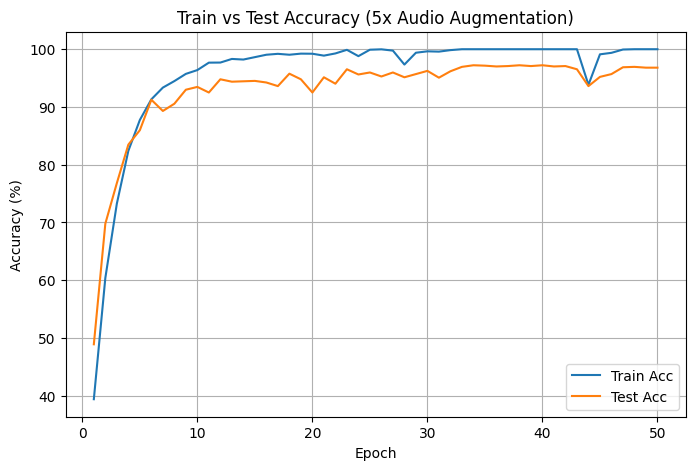

In [ ]:

# SER on RAVDESS with 5x Audio Augmentation 
import os
import random
import gc

import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from skimage.transform import resize
import matplotlib.pyplot as plt

#Device/DRIVE GPU SETUP 
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


audio_dir = "/content/drive/MyDrive/audio_speech_actors_01-24" 

sample_rate = 16000
resize_dim = 128 


# RAVDESS LABEL ENCODING

def get_emotion_id_from_ravdess(filename):

    RAVDESS naming: '03-01-05-02-02-01-12.wav'

    try:
        base = os.path.basename(filename)
        parts = base.split('.')[0].split('-')
        return int(parts[2]) 
    except Exception:
        return None





def augment_audio_4x(y, sr):
    aug_list = []

    # 1. Gaussian noise
    noise = np.random.normal(0, 0.005, y.shape)
    aug_list.append(y + noise)

    # 2. Time shift (±25% length)
    max_shift = int(0.25 * len(y))
    if max_shift > 0:
        shift = random.randint(-max_shift, max_shift)
        aug_list.append(np.roll(y, shift))
    else:
        aug_list.append(y.copy())

    # 3. Pitch shift (±2 semitones)
    try:
        aug_list.append(librosa.effects.pitch_shift(y, sr, n_steps=random.choice([-2, 2])))
    except Exception:
        aug_list.append(y.copy())

    # 4. Time stretch (0.8x or 1.2x)
    rate = random.choice([0.8, 1.2])
    try:
        stretched = librosa.effects.time_stretch(y, rate)
        if len(stretched) > 0:
            aug_list.append(stretched)
        else:
            aug_list.append(y.copy())
    except Exception:
        aug_list.append(y.copy())


    return aug_list


# MEL-SPECTROGRAM CREATION (in RAM only for avoiding I/O drive delay )

def audio_to_mel_spec(y, sr, resize_dim=128):
    """
    Convert 1D audio to 128 x 128 Mel-spectrogram.
    """
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=256,
        n_mels=resize_dim
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)  

#Resize MEl SPECTOGRAM
    mel_resized = resize(mel_db, (resize_dim, resize_dim), mode='reflect', anti_aliasing=True)
    return mel_resized.astype(np.float32)


all_specs = []
all_labels = []

print("Building 5x augmented dataset from audio ...")

for root, dirs, files in os.walk(audio_dir):
    for fname in files:
        if not fname.lower().endswith(".wav"):
            continue

        fpath = os.path.join(root, fname)
        emotion_id = get_emotion_id_from_ravdess(fname)
        if emotion_id is None:
            continue


        label = emotion_id - 1


        # 1) Original
        spec_orig = audio_to_mel_spec(y, sr, resize_dim)
        all_specs.append(spec_orig)
        all_labels.append(label)


        aug_audios = augment_audio_4x(y, sr)
        for y_aug in aug_audios:
            spec_aug = audio_to_mel_spec(y_aug, sr, resize_dim)
            all_specs.append(spec_aug)
            all_labels.append(label)

print("Total samples after 5x augmentation:", len(all_specs))

all_specs = np.stack(all_specs, axis=0)  
all_labels = np.array(all_labels)
print("Specs shape:", all_specs.shape, "Labels shape:", all_labels.shape)


all_specs = all_specs[:, np.newaxis, :, :]


# TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    all_specs, all_labels, test_size=0.2, random_state=seed, stratify=all_labels
)

X_train_tensor = torch.tensor(X_train).float().to(device)
y_train_tensor = torch.tensor(y_train).long().to(device)
X_test_tensor  = torch.tensor(X_test ).float().to(device)
y_test_tensor  = torch.tensor(y_test ).long().to(device)

print("Train:", X_train_tensor.shape, "Test:", X_test_tensor.shape)


# BASELINE MODEL: CNN + BLSTM + ATTENTION

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (B, T, H)
        weights = torch.softmax(self.attn(x), dim=1)  
        out = torch.sum(weights * x, dim=1)          
        return out

class CNN_BLSTM_Attention(nn.Module):
    def __init__(self, num_classes,
                 lstm_hidden=128,
                 dropout_rate=0.3,
                 cnn1_filters=32,
                 cnn2_filters=64,
                 cnn3_filters=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, cnn1_filters, 3, padding=1),
            nn.BatchNorm2d(cnn1_filters),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(cnn1_filters, cnn2_filters, 3, padding=1),
            nn.BatchNorm2d(cnn2_filters),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(cnn2_filters, cnn3_filters, 3, padding=1),
            nn.BatchNorm2d(cnn3_filters),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.lstm_hidden = lstm_hidden
        self.lstm = nn.LSTM(cnn3_filters * 16,
                            lstm_hidden,
                            batch_first=True,
                            bidirectional=True)
        self.attention = Attention(lstm_hidden * 2)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)

    def forward(self, x):
     
        cnn_out = self.cnn(x)            
        b, c, h, w = cnn_out.shape          
        seq = cnn_out.permute(0, 3, 1, 2).reshape(b, w, c*h)  
        lstm_out, _ = self.lstm(seq)        
        attn = self.attention(lstm_out)     
        logits = self.fc(self.dropout(attn))
        return logits

num_classes = len(np.unique(y_train))
print("Num classes:", num_classes)


def make_optimizer(params, model_params):
    opt_name = params['optimizer']
    lr = params['lr']
    wd = params['weight_decay']
    if opt_name == 'Adam':
        return optim.Adam(model_params, lr=lr, weight_decay=wd)
    elif opt_name == 'AdamW':
        return optim.AdamW(model_params, lr=lr, weight_decay=wd)
    else:
        return optim.RMSprop(model_params, lr=lr, weight_decay=wd, momentum=0.9)

def grey_wolf_optimizer(X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor,
                        n_wolves=4, iterations=3, epochs_per_wolf=3):

    def random_params():
        return {
            'lr': 10 ** random.uniform(-4, -2),
            'weight_decay': 10 ** random.uniform(-6, -3),
            'dropout_rate': random.uniform(0.2, 0.5),
            'lstm_hidden': random.choice([64, 96, 128, 160]),
            'cnn1_filters': random.choice([16, 32, 48, 64]),
            'cnn2_filters': random.choice([32, 64, 96]),
            'cnn3_filters': random.choice([64, 96, 128, 160]),
            'optimizer': random.choice(['Adam', 'AdamW', 'RMSprop']),
            'batch_size': random.choice([16, 32, 64]),
        }

    def clamp_params(p):
        def snap(val, choices):
            return min(choices, key=lambda c: abs(c - val))

        p['lr'] = float(min(max(p['lr'], 1e-4), 1e-2))
        p['weight_decay'] = float(min(max(p['weight_decay'], 0.0), 1e-3))
        p['dropout_rate'] = float(min(max(p['dropout_rate'], 0.2), 0.5))

        valid_cnn = [16, 32, 48, 64, 96, 128, 160,192,224,256]
        valid_lstm = [64, 96, 128, 160,192,224,256]
        valid_bs   = [16, 32, 64]

        p['cnn1_filters'] = int(snap(int(p['cnn1_filters']), valid_cnn))
        p['cnn2_filters'] = int(snap(int(p['cnn2_filters']), valid_cnn))
        p['cnn3_filters'] = int(snap(int(p['cnn3_filters']), valid_cnn))
        p['lstm_hidden']  = int(snap(int(p['lstm_hidden']),  valid_lstm))
        p['batch_size']   = int(snap(int(p['batch_size']),   valid_bs))

        if p.get('optimizer') not in ['Adam', 'AdamW', 'RMSprop']:
            p['optimizer'] = 'Adam'

        return p

    def fitness(params):
        torch.cuda.empty_cache()
        gc.collect()

        model = CNN_BLSTM_Attention(
            num_classes,
            lstm_hidden=params['lstm_hidden'],
            dropout_rate=params['dropout_rate'],
            cnn1_filters=params['cnn1_filters'],
            cnn2_filters=params['cnn2_filters'],
            cnn3_filters=params['cnn3_filters']
        ).to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer_ = make_optimizer(params, model.parameters())

        train_loader_local = DataLoader(
            TensorDataset(X_train_tensor, y_train_tensor),
            batch_size=params['batch_size'],
            shuffle=True
        )

        model.train()
        for _ in range(epochs_per_wolf):
            for xb, yb in train_loader_local:
                optimizer_.zero_grad()
                out = model(xb)
                loss = criterion(out, yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer_.step()

        model.eval()
        with torch.no_grad():
            preds = torch.argmax(model(X_val_tensor), dim=1)
            acc = (preds == y_val_tensor).float().mean().item()

        return acc

    # Initializing wolves
    wolves = [random_params() for _ in range(n_wolves)]
    fitness_vals = [fitness(w) for w in wolves]

    for t in range(iterations):
        alpha_idx = int(np.argmax(fitness_vals))
        alpha = wolves[alpha_idx]
        print(f"GWO Iter {t+1}/{iterations} | Best Acc so far: {fitness_vals[alpha_idx]*100:.2f}%")

        a = 2 - t * (2 / iterations)

        new_wolves, new_fitness = [], []
        for i in range(n_wolves):
            wolf = wolves[i]
            new_wolf = {}
            for k in wolf:
                if k == 'optimizer':
                    # keep alpha or random new
                    new_wolf[k] = alpha[k] if random.random() < 0.5 else random.choice(['Adam', 'AdamW', 'RMSprop'])
                    continue

                r1, r2 = random.random(), random.random()
                A = 2 * a * r1 - a
                C = 2 * r2
                D = abs(C * alpha[k] - wolf[k])
                new_val = alpha[k] - A * D
                new_wolf[k] = new_val

            new_wolf = clamp_params(new_wolf)
            acc = fitness(new_wolf)
            new_wolves.append(new_wolf)
            new_fitness.append(acc)

        combined_wolves = wolves + new_wolves
        combined_fitness = fitness_vals + new_fitness
        best_idx = np.argsort(combined_fitness)[-n_wolves:]

        wolves = [combined_wolves[i] for i in best_idx]
        fitness_vals = [combined_fitness[i] for i in best_idx]

    best_idx = int(np.argmax(fitness_vals))
    return wolves[best_idx], fitness_vals[best_idx]


#Running GWO

best_params, best_acc = grey_wolf_optimizer(
    X_train_tensor, y_train_tensor,
    X_test_tensor, y_test_tensor,
    n_wolves=4, iterations=3, epochs_per_wolf=3
)

print("\nBest Params Found by GWO:", best_params)
print(f"GWO Validation Accuracy: {best_acc*100:.2f}%")

#EPoch Training on Best Parameteres found by GWO
final_model = CNN_BLSTM_Attention(
    num_classes,
    lstm_hidden=best_params['lstm_hidden'],
    dropout_rate=best_params['dropout_rate'],
    cnn1_filters=best_params['cnn1_filters'],
    cnn2_filters=best_params['cnn2_filters'],
    cnn3_filters=best_params['cnn3_filters']
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_final = make_optimizer(best_params, final_model.parameters())

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=best_params['batch_size'],
    shuffle=True
)

epochs = 50
train_acc_list = []
test_acc_list = []

for epoch in range(epochs):
    final_model.train()
    correct_train, total_train = 0, 0

    for xb, yb in train_loader:
        optimizer_final.zero_grad()
        out = final_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(final_model.parameters(), 5.0)
        optimizer_final.step()

        preds = torch.argmax(out, dim=1)
        correct_train += (preds == yb).sum().item()
        total_train += yb.size(0)

    epoch_train_acc = correct_train / total_train

    final_model.eval()
    with torch.no_grad():
        preds_test = torch.argmax(final_model(X_test_tensor), dim=1)
        epoch_test_acc = (preds_test == y_test_tensor).float().mean().item()

    train_acc_list.append(epoch_train_acc)
    test_acc_list.append(epoch_test_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {epoch_train_acc*100:.2f}% | Test Acc: {epoch_test_acc*100:.2f}%")

#MatPLOT
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), [a*100 for a in train_acc_list], label="Train Acc")
plt.plot(range(1, epochs+1), [a*100 for a in test_acc_list], label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Test Accuracy (5x Audio Augmentation)")
plt.legend()
plt.grid(True)
plt.show()
